In [25]:
import numpy as np
import pandas as pd
import dynesty
from dynesty import plotting as dyplot
from dynesty.utils import resample_equal
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from math import floor, log10
import plotfancy as pf


In [26]:


# ---------------------------------------------------------------------------
# 1.  Load data
# ---------------------------------------------------------------------------
try:
    df = pd.read_csv("MW_PEAS.csv")
except FileNotFoundError:
    print("Error: MW_PEAS.csv not found. Please ensure the data file is in the correct directory.")
    exit()

mask = (df['STELLAR_MASS'].values > 0) & (df["Z_dir_gen"] > 0) & (df["Z_dir_gen_err"] > 1e-5)

log_mass = df["STELLAR_MASS"].values[mask]           # log10(M*/Msun)
mass_err = 0.3 * np.ones(len(log_mass))     # uncertainty on log_mass
log_OH = df["Z_dir_gen"].values[mask]             # 12 + log(O/H)  measured
OH_err_up = 5 * df["Z_dir_gen_err"].values[mask]        # upper metallicity uncertainty
OH_err_lo = 5 * df["Z_dir_gen_err"].values[mask]        # lower metallicity uncertainty

N = len(log_mass)

# Number of mass draws per galaxy per likelihood call.
# Increase for more accurate marginalisation (slower); 20 is a good default.
N_MASS_DRAWS = 20


# ---------------------------------------------------------------------------
# 2.  MZR model
# ---------------------------------------------------------------------------
def model_OH(log_mass_draw, gamma_g, Z_g10):
    """Eq. 2:  predicted 12+log(O/H) given log stellar mass."""
    return gamma_g * (log_mass_draw - 10.0) + Z_g10


# ---------------------------------------------------------------------------
# 3.  Split-normal sigma (Eq. A2)
# ---------------------------------------------------------------------------
def sigma_i(OH_model, OH_truth, err_up, err_lo):
    return np.where(OH_model >= OH_truth, err_up, err_lo)


# ---------------------------------------------------------------------------
# 4.  Averaged log-likelihood over mass draws
# ---------------------------------------------------------------------------
def _mass_averaged_terms(gamma_g, Z_g10):
    mass_draws = np.random.normal(log_mass, mass_err,
                                  size=(N_MASS_DRAWS, N))
    OH_model = model_OH(mass_draws, gamma_g, Z_g10)
    sig = sigma_i(OH_model, log_OH, OH_err_up, OH_err_lo)
    sig2 = sig ** 2

    ln_inlier_draws = (
        -0.5 * np.log(2.0 * np.pi * sig2)
        - 0.5 * ((log_OH - OH_model) ** 2) / sig2
    )
    ln_inlier = logsumexp(ln_inlier_draws, axis=0) - np.log(N_MASS_DRAWS)
    mean_sig2 = np.mean(sig2, axis=0)
    return ln_inlier, mean_sig2


# ---------------------------------------------------------------------------
# 5a.  Mode A: no outlier rejection  (Eq. A1)
# ---------------------------------------------------------------------------
def ln_likelihood_normal(theta):
    gamma_g, Z_g10 = theta
    ln_inlier, _ = _mass_averaged_terms(gamma_g, Z_g10)
    return float(np.sum(ln_inlier))


# ---------------------------------------------------------------------------
# 5b.  Mode B: outlier-robust, q_i marginalised analytically (Eq. A3 + A4)
# ---------------------------------------------------------------------------
def ln_likelihood_prune(theta):
    """
    q_i marginalised analytically over [0,1] with a flat prior.
 
    For each galaxy:
        A_i = ln p(data_i | inlier)  + ln(1 - P_b)
        B_i = ln p(data_i | outlier) + ln(P_b)
        ln p(data_i) = logsumexp([A_i, B_i])
 
    Note: no - log(2) term; A and B already encode the mixture weights.
    """
    gamma_g, Z_g10, P_b, Y_b, V_b = theta
 
    if P_b <= 0.0 or P_b >= 1.0 or V_b <= 0.0:
        return -np.inf
 
    ln_inlier, mean_sig2 = _mass_averaged_terms(gamma_g, Z_g10)
 
    V_eff = V_b + mean_sig2
    ln_outlier = (
        -0.5 * np.log(2.0 * np.pi * V_eff)
        - 0.5 * ((log_OH - Y_b) ** 2) / V_eff
    )
 
    A = ln_inlier  + np.log(1.0 - P_b)
    B = ln_outlier + np.log(P_b)
    ln_marg = logsumexp(np.stack([A, B], axis=0), axis=0)
 
    return float(np.sum(ln_marg))


# ---------------------------------------------------------------------------
# 6.  Prior transforms
# ---------------------------------------------------------------------------
def prior_transform_normal(u):
    return np.array([3.0 * u[0], 6.0 + 3.0 * u[1]])


def prior_transform_prune(u):
    gamma_g = 3.0  * u[0]               # U(0, 1)
    Z_g10   = 6.0  + 5.0 * u[1]         # U(6, 11)
    P_b     = 1.0  * u[2]               # U(0, 1)  
    Y_b     = 6.0  + 3.0 * u[3]         # U(6, 9)
    V_b     = 4.0  * u[4]               # U(0, 4)
    return np.array([gamma_g, Z_g10, P_b, Y_b, V_b])


# ---------------------------------------------------------------------------
# 7.  Run Nested Sampling
# ---------------------------------------------------------------------------
OUTLIER_MODE = True

if not OUTLIER_MODE:
    ndim, loglike, prior_transform = 2, ln_likelihood_normal, prior_transform_normal
    param_labels = [r"$\gamma_g$", r"$Z_{g,10}$"]
else:
    ndim, loglike, prior_transform = 5, ln_likelihood_prune, prior_transform_prune
    param_labels = [r"$\gamma_g$", r"$Z_{g,10}$", r"$P_b$", r"$Y_b$", r"$V_b$"]

sampler = dynesty.NestedSampler(
    loglike,
    prior_transform,
    ndim,
    nlive=500,
    sample="rwalk",
)
sampler.run_nested(dlogz=0.1, print_progress=True)
results = sampler.results


# ---------------------------------------------------------------------------
# 8.  Extract best-fit parameters
# ---------------------------------------------------------------------------
weights = np.exp(results.logwt - results.logz[-1])


samples = resample_equal(results.samples, weights)
 
for i, label in enumerate(param_labels):
    lo, med, hi = np.percentile(samples[:, i], [16, 50, 84])
    print(f"{label:>12s}  =  {med:.3f}  +{hi-med:.3f} / -{med-lo:.3f}")


# ---------------------------------------------------------------------------
# 9.  Infer per-galaxy outlier probabilities (Mode B only)
# ---------------------------------------------------------------------------
if OUTLIER_MODE:
    gamma_g_best, Z_g10_best, P_b_best, Y_b_best, V_b_best = np.median(samples, axis=0)

    ln_inlier, mean_sig2 = _mass_averaged_terms(gamma_g_best, Z_g10_best)
    V_eff = V_b_best + mean_sig2
    ln_outlier = (
        -0.5 * np.log(2.0 * np.pi * V_eff)
        - 0.5 * ((log_OH - Y_b_best) ** 2) / V_eff
    )
    A = ln_inlier  + np.log(1.0 - P_b_best)
    B = ln_outlier + np.log(P_b_best)
    log_norm = logsumexp(np.stack([A, B], axis=0), axis=0)
    q_best   = np.exp(A - log_norm)

    df["q_inlier"] = q_best



11230it [01:11, 157.22it/s, +500 | bound: 127 | nc: 1 | ncall: 254498 | eff(%):  4.618 | loglstar:   -inf < -135.394 <    inf | logz: -155.537 +/-  0.187 | dlogz:  0.000 >  0.100]

  $\gamma_g$  =  0.118  +0.033 / -0.033
  $Z_{g,10}$  =  8.478  +0.045 / -0.044
       $P_b$  =  0.650  +0.042 / -0.042
       $Y_b$  =  7.803  +0.034 / -0.031
       $V_b$  =  0.087  +0.013 / -0.012


In [7]:

def round_to_1sf_of(ref):
    """Return the number of decimal places needed to express ref to 1 s.f."""
    if ref == 0:
        return 0
    mag = floor(log10(abs(ref)))
    return max(0, -mag)


def format_title(val, low, high):
    """
    Round each error to 1 s.f., then round val to match the precision of
    whichever rounded error is more precise (i.e. more decimal places).
    """
    def round_err_to_1sf(e):
        if e == 0:
            return 0.0, 0
        mag   = floor(log10(abs(e)))
        scale = 10 ** mag
        rounded = round(e / scale) * scale
        dp = max(0, -mag)
        return rounded, dp

    low_r,  dp_low  = round_err_to_1sf(low)
    high_r, dp_high = round_err_to_1sf(high)
    dp = max(dp_low, dp_high)

    val_r = round(val, dp)
    fmt = f'{{:.{dp}f}}'
    return f'${fmt.format(val_r)}^{{+{fmt.format(high_r)}}}_{{-{fmt.format(low_r)}}}$'

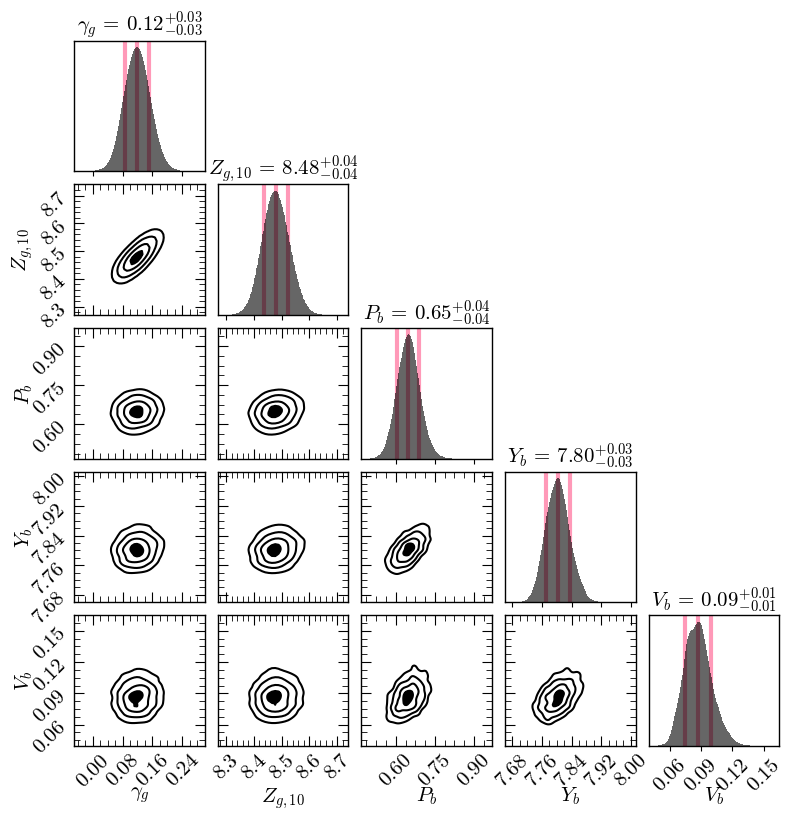

In [24]:
pf.housestyle_rcparams()

param_labels = [r"$\gamma_g$", r"$Z_{g,10}$", r"$P_b$", r"$Y_b$", r"$V_b$"]
ndim = len(param_labels)
fig, axes = plt.subplots(ndim, ndim, figsize=(8, 8))
fig, axes = dyplot.cornerplot(results, labels=param_labels, show_titles=True,
                               title_kwargs={"fontsize": 15},
                               fig=(fig, axes))
fig.subplots_adjust(wspace=0.1,hspace=0.1)

list_of_axes = []
for i in range(len(param_labels)):
    for j in range(len(param_labels)):
        if i != j:
            list_of_axes.append(axes[i, j])

weights = np.exp(results.logwt - results.logz[-1])  # normalised weights

for i in range(ndim):
    ax = axes[i, i]
    qs = [0.16, 0.50, 0.84]
    q_lo, q50, q_hi = dynesty.utils.quantile(results.samples[:, i], qs, weights=weights)

    # Remove existing quantile lines dyplot drew
    for line in ax.lines[:]:
        line.remove()   

    # Redraw with your quantiles
    ax.set_ylim(*ax.get_ylim())

    ymin, ymax = ax.get_ylim()
    for q in [q_lo, q50, q_hi]:
        ax.axvline(q, ymin=-10, ymax=10, color="#ff004f", ls="-", lw=3, alpha=0.4,zorder=-10)

    low  = q50 - q_lo
    high = q_hi - q50
    title = format_title(q50, low, high)
    title = f"{param_labels[i]} = {title}"
    ax.set_title(title, fontsize=15)

for i in range(ndim):
    axes[i, 0].set_xlim(-0.05, 0.3)
    axes[i, 1].set_xlim(8.27,8.74) 

axes[1, 0].set_ylim(8.27,8.74) 

pf.fix_plot(list_of_axes)
fig.savefig(f'figs/mwcorner.pdf', dpi=600, bbox_inches='tight')